In [2]:
import torch 
import numpy 
import torch.optim as optim
import torch.nn.functional as F
import torch.nn as nn 
import torch.distributions as distributions 

import gymnasium as gym 

In [3]:
# train env 

train_env = gym.make("CartPole-v1")
test_env = gym.make("CartPole-v1")

In [4]:
SEED = 42
torch.manual_seed = SEED 
numpy.random.seed = SEED 

In [5]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(p= dropout)
    
    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [6]:
class ActorCritic(nn.Module):
    def __init__(self, actor, critic):
        super().__init__()
        self.actor = actor 
        self.critic = critic 
    
    def forward(self, state):
        action_pred = self.actor(state)
        value_pred = self.critic(state)
        return action_pred, value_pred


In [7]:
INPUT_DIM = train_env.observation_space.shape[0]
OUPUT_DIM = train_env.action_space.n 
HIDDEN_DIM = 128
actor = MLP(INPUT_DIM, HIDDEN_DIM, OUPUT_DIM, 0.1)
critic = MLP(INPUT_DIM, HIDDEN_DIM, 1, 0.1)


policy = ActorCritic(actor, critic)
policy, actor, critic 

(ActorCritic(
   (actor): MLP(
     (fc1): Linear(in_features=4, out_features=128, bias=True)
     (fc2): Linear(in_features=128, out_features=2, bias=True)
     (dropout): Dropout(p=0.1, inplace=False)
   )
   (critic): MLP(
     (fc1): Linear(in_features=4, out_features=128, bias=True)
     (fc2): Linear(in_features=128, out_features=1, bias=True)
     (dropout): Dropout(p=0.1, inplace=False)
   )
 ),
 MLP(
   (fc1): Linear(in_features=4, out_features=128, bias=True)
   (fc2): Linear(in_features=128, out_features=2, bias=True)
   (dropout): Dropout(p=0.1, inplace=False)
 ),
 MLP(
   (fc1): Linear(in_features=4, out_features=128, bias=True)
   (fc2): Linear(in_features=128, out_features=1, bias=True)
   (dropout): Dropout(p=0.1, inplace=False)
 ))

In [8]:
def init_weight(model):
    if type(model) == nn.Linear:
        torch.nn.init.xavier_normal_(model.weight)
        model.bias.data.fill_(0)

policy.apply(init_weight)
policy

ActorCritic(
  (actor): MLP(
    (fc1): Linear(in_features=4, out_features=128, bias=True)
    (fc2): Linear(in_features=128, out_features=2, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (critic): MLP(
    (fc1): Linear(in_features=4, out_features=128, bias=True)
    (fc2): Linear(in_features=128, out_features=1, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)

In [9]:
LEARNING_RATE = 0.001

optimizer = optim.Adam(policy.parameters(), lr = LEARNING_RATE)
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

In [10]:
def train_monte_carlo(env, policy, optimizer, discounted_factor, ppo_step, ppo_clip):
    policy.train() 

    values = []
    rewards = []
    actions= []
    log_prob_actions = []
    states = []
    episode_reward = 0

    state, _ = env.reset()

    done = False 
    truncated = False 

    while not done and not truncated : 

        state = torch.tensor(state).unsqueeze(0)
        states.append(state)
        action_pred, value_pred = policy(state)
        #chuyen sang softmax cho action_pred 
        action_log_pred = F.softmax(action_pred, dim = -1)
        dict = distributions.Categorical(action_log_pred)
        action = dict.sample()
        log_prob_action = dict.log_prob(action)

        state, reward , done, truncated, _ = env.step(action.item())

        # save 
        values.append(value_pred)
        rewards.append(reward)
        actions.append(action)
        log_prob_actions.append(log_prob_action)

        episode_reward += reward 

    states = torch.cat(states) # [1, s] -> [N, s]
    actions = torch.cat(actions) # [1] -> [N]
    log_prob_actions = torch.cat(log_prob_actions)  # [1] -> [n]
    values = torch.cat(values).squeeze(-1) # [1, 1] -> [N, 1] -> [N]

    returns = monte_carlo(rewards, discounted_factor)
    advantages = Advantages(returns, values)
    policy_loss, values_loss = update_policy(policy, states, actions, log_prob_actions, returns, advantages, optimizer, ppo_step, ppo_clip)
    return policy_loss, values_loss, episode_reward


In [11]:
def monte_carlo(rewards, discounted_factor):
    R = 0
    returns = []
    for reward in reversed(rewards):
        R = reward + R * discounted_factor
        returns.insert(0, R) # gắn vào giá trị đầu tiên , ko dược dùng append, vì ta đang đi từ terminate đến start
    returns = torch.tensor(returns)

    return (returns - returns.mean()) / returns.std()


In [12]:
def Advantages(returns, values):
    advantages = returns - values 

    return (advantages - advantages.mean()) / advantages.std()

In [13]:
def update_policy(policy, states, actions, log_prob_actions, returns, advantages, optimizer, ppo_step, ppo_clip):
    total_policy_loss = 0 
    total_value_loss = 0

    #detach những dữ liệu lịch sử, ko cho model truy về những dữ liệu này để cập nhật, nó là dữ liệu lịch sử ,ko thể thay đổi
    advantages = advantages.detach()
    actions = actions.detach()
    log_prob_actions = log_prob_actions.detach()

    for _ in range(ppo_step):

        # Lấy log_prob_action cho action mới  của tất cả state được lưu 
        actions_pred, values_pred = policy(states)
        values_pred = values_pred.squeeze(-1)
        actions_prob = F.softmax(actions_pred, dim = -1) # [N]
        dict = distributions.Categorical(actions_prob)
        new_log_prob_actions = dict.log_prob(actions) # [N]

        #ratio giữa policy mới và cũ * Advantage
        policy_ratio = (new_log_prob_actions - log_prob_actions).exp() # N - N = N

        # tính toán Surrogate Loss (phần cắt tỉa - Clipping)
        policy_loss1 = policy_ratio * advantages # N * N = elemenwise(N)
        policy_loss2 = torch.clamp(policy_ratio, 1 - ppo_clip, 1 + ppo_clip) * advantages

        # Tổng hợp Loss (Dấu trừ để chuyển từ Maximize Advantage sang Minimize Loss)
        # .mean() hoặc .sum() sẽ biến [N] thành [1]
        policy_loss = - torch.min(policy_loss1, policy_loss2).sum()

        value_loss = F.smooth_l1_loss(returns, values_pred).sum()

        optimizer.zero_grad()

        policy_loss.backward()
        value_loss.backward()

        optimizer.step()

        total_policy_loss += policy_loss 
        total_value_loss += value_loss 

    return total_policy_loss, total_value_loss



In [14]:
def evaluate(env, policy, render = True):
    policy.eval()

    done = False 
    truncated = False 
    episode_reward = 0
    
    state, _ = env.reset()
    while not done and not truncated:
        state = torch.tensor(state).unsqueeze(0) #[1, state_dim]
        with torch.no_grad():
            action_pred, _ = policy(state)
            action_prob = F.softmax(action_pred, dim = -1)

        action = torch.argmax(action_prob, dim = -1)
        state, reward, done, truncated, _ = env.step(action.item())

        episode_reward += reward 

    return episode_reward 

        
        

        

In [15]:
import cv2
import torch
import torch.nn as nn

def test(env, policy, episodes, render=True):
    policy.eval()
    frames = []
    
    for episode in range(episodes):
        done = False
        truncated = False
        episode_reward = 0
        state, _ = env.reset()
        
        while not done and not truncated:
            state_t = torch.FloatTensor(state).unsqueeze(0)

            with torch.no_grad():
                action_pred, _ = policy(state_t)
                
            action = torch.argmax(action_pred, dim=-1)
            state, reward, done, truncated, _ = env.step(action.item())
            episode_reward += reward
            
            if render:
                frame = env.render() # Lấy RGB array từ gym
                
                # Chuyển RGB sang BGR để OpenCV vẽ text và ghi video đúng màu
                frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
                
                # Vẽ số episode lên frame
                cv2.putText(
                    frame, f"Episode: {episode} | Reward: {int(episode_reward)}",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2
                )
                frames.append(frame)
                
        print(f"Ep {episode} | Reward: {episode_reward}")

    # Kiểm tra nếu có frames thì mới ghi video
    if render and len(frames) > 0:
        height, width = frames[0].shape[:2]
        # Sử dụng 'avc1' hoặc 'mp4v'. Lưu ý: tên file nên có đuôi .mp4
        out = cv2.VideoWriter(
            "output_video.mp4", 
            cv2.VideoWriter_fourcc(*"mp4v"), 
            30, 
            (width, height)
        )

        for f in frames:
            out.write(f)
            
        out.release()
        print("✅ Video saved as output_video.mp4")
    else:
        print("⚠️ No frames to save.")

In [16]:
NUM_EPISODES = 500
DISCOUNTED_FACTOR  = 0.99
N_TRIALS = 25
PPO_STEP = 5
REWARD_THRESHOLD = 480
PRINT_EVERY = 10
PPO_CLIP = 0.2


train_rewards = []
eval_rewards = []

for episode in range(1, NUM_EPISODES + 1):
    policy_loss, values_loss, train_reward = train_monte_carlo(train_env, policy, optimizer, DISCOUNTED_FACTOR, PPO_STEP, PPO_CLIP)

    test_reward = evaluate(test_env, policy)
    train_rewards.append(train_reward)
    eval_rewards.append(test_reward)

    mean_train_rewards = torch.tensor(train_rewards[-N_TRIALS:]).mean()
    mean_test_rewards = torch.tensor(eval_rewards[-N_TRIALS:]).mean()

    if episode % PRINT_EVERY == 0:
        print(f'| Episode: {episode:3} | Mean Train Rewards: {mean_train_rewards:5.1f} | Mean Test Rewards: {mean_test_rewards:5.1f} |')

    if mean_test_rewards >= REWARD_THRESHOLD:
        print("REACHED REWARD threshold in {episode}: episode")
        break


| Episode:  10 | Mean Train Rewards:  25.8 | Mean Test Rewards: 108.7 |
| Episode:  20 | Mean Train Rewards:  34.8 | Mean Test Rewards:  92.4 |
| Episode:  30 | Mean Train Rewards:  45.7 | Mean Test Rewards:  81.0 |
| Episode:  40 | Mean Train Rewards:  69.5 | Mean Test Rewards:  95.9 |
| Episode:  50 | Mean Train Rewards:  96.4 | Mean Test Rewards: 178.7 |
| Episode:  60 | Mean Train Rewards: 105.5 | Mean Test Rewards: 191.0 |
| Episode:  70 | Mean Train Rewards:  93.5 | Mean Test Rewards: 133.1 |
| Episode:  80 | Mean Train Rewards: 110.3 | Mean Test Rewards: 190.1 |
| Episode:  90 | Mean Train Rewards: 179.3 | Mean Test Rewards: 346.6 |
| Episode: 100 | Mean Train Rewards: 278.0 | Mean Test Rewards: 465.9 |
| Episode: 110 | Mean Train Rewards: 355.1 | Mean Test Rewards: 473.9 |
REACHED REWARD threshold in {episode}: episode


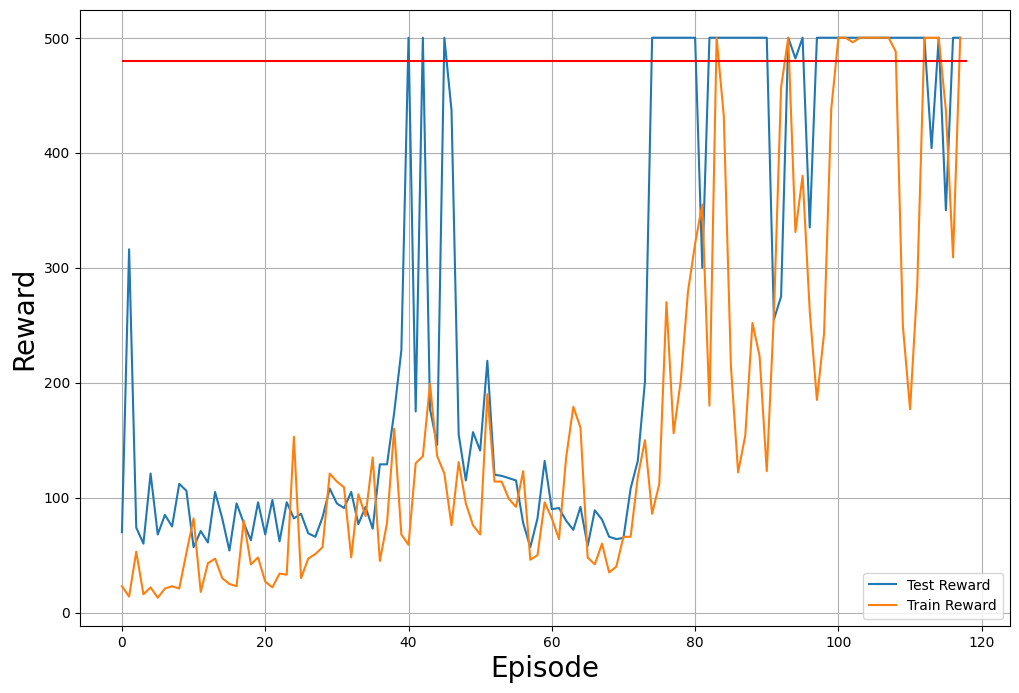

In [17]:
import matplotlib.pyplot as plt
REWARD_THRESHOLD = 480
plt.figure(figsize=(12,8))
plt.plot(eval_rewards, label='Test Reward')
plt.plot(train_rewards, label='Train Reward')
plt.xlabel('Episode', fontsize=20)
plt.ylabel('Reward', fontsize=20)
plt.hlines(REWARD_THRESHOLD, 0, len(eval_rewards), color='r')
plt.legend(loc='lower right')
plt.grid()

In [18]:
test_env = gym.make('CartPole-v1', render_mode='rgb_array')
test(test_env, policy, 10, render = True)

objc[33802]: Class SDLApplication is implemented in both /Users/felix/RL_Projects/.venv/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x11ca94890) and /Users/felix/RL_Projects/.venv/lib/python3.13/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1311fd2c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[33802]: Class SDLAppDelegate is implemented in both /Users/felix/RL_Projects/.venv/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x11ca948e0) and /Users/felix/RL_Projects/.venv/lib/python3.13/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1311fd318). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[33802]: Class SDLTranslatorResponder is implemented in both /Users/felix/RL_Projects/.venv/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x11ca94958) and /Users/felix/RL_Projects/.venv/lib/python

Ep 0 | Reward: 500.0
Ep 1 | Reward: 500.0
Ep 2 | Reward: 500.0
Ep 3 | Reward: 500.0
Ep 4 | Reward: 500.0
Ep 5 | Reward: 500.0
Ep 6 | Reward: 500.0
Ep 7 | Reward: 500.0
Ep 8 | Reward: 500.0
Ep 9 | Reward: 500.0
✅ Video saved as output_video.mp4


In [ ]:
!ls -lh output_video.mp4

-rw-r--r--@ 1 felix  staff   9.1M Apr 27 11:44 output_video.mp4
